Total runtime: 0.1128 seconds
Average loss (0.5–3 THz): 6.034246e-05


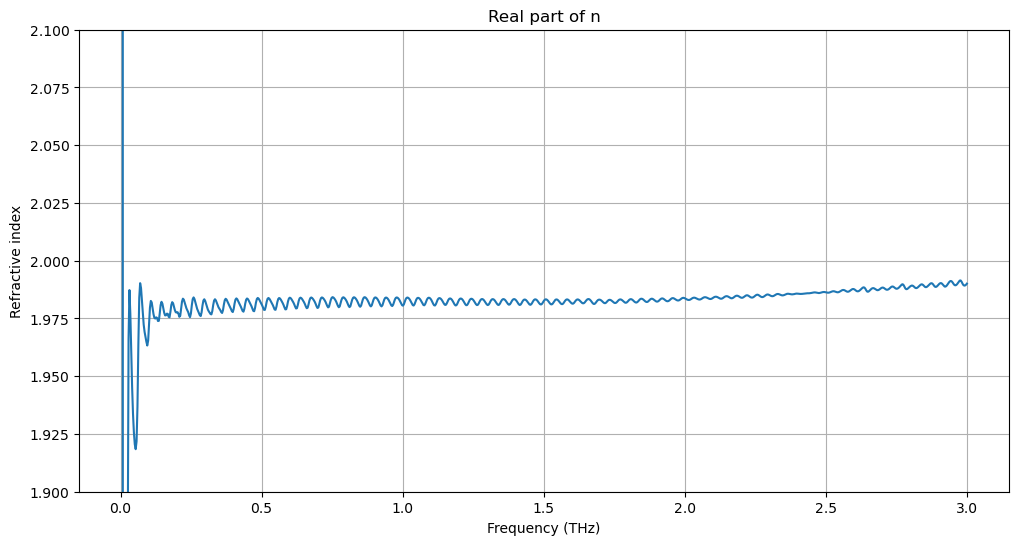

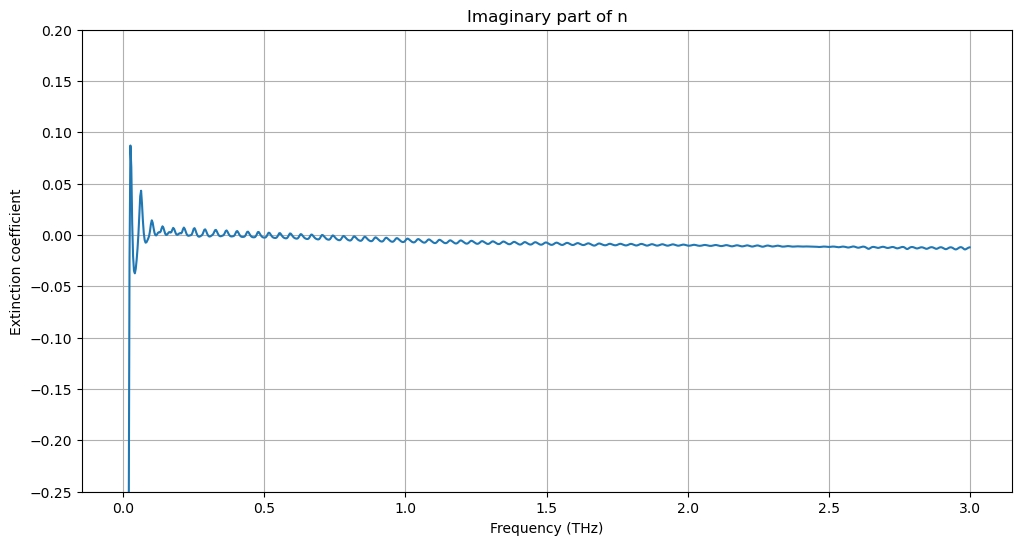

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

# START TIMER
start_time = time.time()

# LOAD DATA
datar = np.loadtxt("2mmR.dat", delimiter=",")
datas = np.loadtxt("2mmS.dat", delimiter=",")
ts = datas[:, 0]
tr = datar[:, 0]
sr = datar[:, 1]
ss = datas[:, 1]

# INTERPOLATION
startt = 0
endt = 4.6116 * 10**-11
dt = min(np.mean(np.diff(ts)), np.mean(np.diff(tr)))
t = np.arange(startt, endt + dt, dt)

sr = np.interp(t, tr, sr, left=0, right=0)
ss = np.interp(t, ts, ss, left=0, right=0)

# FFT
fftr = np.fft.fft(sr, 16384)
ffts = np.fft.fft(ss, 16384)
freq = np.fft.fftfreq(16384, dt)

# MASK
mask = (freq > 0) & (freq < 3.0 * 10**12)
fftr = fftr[mask]
ffts = ffts[mask]
freq = freq[mask]

# TRANSFER FUNCTION
tf = ffts / fftr
phase_unwrapped = np.unwrap(np.angle(tf))
phase_unwrapped -= phase_unwrapped[0] - 1.9

# FUNCTIONS
def F(n, f, lnH_exp):
    lnH_th = (np.log((4 * n) / ((1 + n) ** 2)) 
              - 1j * 2e-3 * (2 * np.pi * f) * (n - 1) / (3e8)
              - np.log(1 - ((n - 1) / (n + 1)) ** 2 
              * np.exp((-4 * 1j * n * np.pi * f * 2e-3) / 3e8)))
    return lnH_th - lnH_exp

def G(n, f):
    x = 1 / n - 2 / (1 + n) - 1j * 2e-3 * (2 * np.pi * f) / 3e8
    y = 2 * ((n - 1) / (n + 1)) ** 2 * np.exp((-4 * 1j * n * np.pi * f * 2e-3) / 3e8)
    s = 1 - ((n - 1) / (n + 1)) ** 2 * np.exp((-4 * 1j * n * np.pi * f * 2e-3) / 3e8)
    z = 1 / (n - 1) - 1 / (n + 1) - 1j * 2e-3 * (2 * np.pi * f) / (3e8)
    return x + y * z / s

def n_r(f, lnH_exp, n_0, iterations=500, tolerance=1e-15):
    n = n_0
    for _ in range(iterations):
        F_ = F(n, f, lnH_exp)
        G_ = G(n, f)
        delta_n = F_ / G_
        n = n - delta_n
        if abs(delta_n) < tolerance:
            break
    return n

# REFRACTIVE INDEX COMPUTATION
n_0 = 2 + 0.05j
n_ = []

for i, f in enumerate(freq):
    lnH_exp = np.log(np.abs(tf[i])) + 1j * phase_unwrapped[i]
    n = n_r(f, lnH_exp, n_0)
    n_.append(n)
    n_0 = n
n_ = np.array(n_)

# THEORETICAL TRANSFER FUNCTION
H_th = (((4 * n_) / ((1 + n_) ** 2)) * np.exp(-1j * 2e-3 * (2 * np.pi * freq) * (n_ - 1) / (3e8))) / (
    1 - (((n_ - 1) / (n_ + 1)) ** 2) * np.exp((-4 * 1j * n_ * np.pi * freq * 2e-3) / 3e8))

# LOSS CALCULATION
loss_per_freq = (np.real(H_th - tf) ** 2 + np.imag(H_th - tf) ** 2)
loss_mask = freq >= 0.5e12  # 0.1 THz to 3 THz
average_loss = np.mean(loss_per_freq[loss_mask])


# END TIMER
end_time = time.time()
runtime = end_time - start_time

# PRINT STATS
print(f"Total runtime: {runtime:.4f} seconds")
print(f"Average loss (0.5–3 THz): {average_loss:.6e}")

# PLOTTING
plt.figure(figsize=(12, 6))
plt.plot(freq * 1e-12, np.real(n_))
plt.title("Real part of n")
plt.xlabel("Frequency (THz)")
plt.ylabel("Refractive index")
plt.grid(True)
plt.ylim(1.9, 2.1)

plt.figure(figsize=(12, 6))
plt.plot(freq * 1e-12, np.imag(n_))
plt.title("Imaginary part of n")
plt.xlabel("Frequency (THz)")
plt.ylabel("Extinction coefficient")
plt.grid(True)
plt.ylim(-0.25, 0.2)

plt.show()
